01 — Negative (pseudo-absence) sampling pipeline
Steps:
  1. Filter positive points by SVI acquisition distance (<= 15m)
  2. Snap retained positives to nearest OSM road edge, record highway type
  3. Compute highway-type distribution among positives
  4. Use that distribution as the target proportion for negative generation
  5. Study area geojson = geographic constraint (enforced via graph_from_polygon)
  6. QC: KDE heatmap + road-length-availability diagnostics
  7. Generate negative points matched to the target proportions, visualize
  8. Export id, lat, lon, highway CSVs for positive and negative

Designed to run in Google Colab. Paste as-is into a single cell, or split
at the "# %%" markers into separate cells (VS Code / Jupytext also read
these directly).

In [ ]:
# --- Install (Colab may not have these by default) ---
!pip install osmnx geopandas shapely pyproj matplotlib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.7/104.7 kB 3.6 MB/s eta 0:00:00


In [ ]:
# --- Mount Google Drive (needed since all paths below live under /content/drive) ---
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
from shapely.geometry import Point, LineString
from shapely.ops import nearest_points
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt

ox.settings.log_console = False
ox.settings.use_cache = True

In [ ]:
# =============================================================================
# CONFIG — adjust these before running
# =============================================================================
POSITIVE_CSV = "/content/drive/MyDrive/crash-dualgraph/data/krakow/positive/metadata_outofrange_removed.csv"

# TODO: confirm this path — placeholder for your study area boundary file
BOUNDARY_GEOJSON = "/content/drive/MyDrive/crash-dualgraph/data/krakow/boundary/study-area.geojson"

OUTPUT_DIR = "/content/drive/MyDrive/crash-dualgraph/data/krakow/negative"

DISTANCE_LIMIT_M = 10      # step 1 — exclude positives whose panorama is farther than this
NETWORK_TYPE = "drive"     # OSM road types considered (excludes footways/cycleways)
NEG_POS_RATIO = 1.0        # negatives generated per retained positive

# NOTE: not one of the 8 requested steps — added as a light safeguard so a
# generated negative can't coincidentally land on/right next to a known
# accident point. Set to 0 to disable this check entirely.
MIN_DIST_FROM_POSITIVE_M = 10

RANDOM_SEED = 42
LOW_AVAILABILITY_FLAG_M = 20  # QC threshold for step 6 warning

os.makedirs(OUTPUT_DIR, exist_ok=True)
rng = np.random.default_rng(RANDOM_SEED)

In [ ]:
# [Step 1] ==================================================================
pos_raw = pd.read_csv(POSITIVE_CSV)
print(f"Loaded {len(pos_raw)} positive records")

pos = pos_raw[pos_raw["status"] == "ok"].copy()
before = len(pos)
pos = pos[pos["distance_m"] <= DISTANCE_LIMIT_M].copy()
print(f"status=='ok': {before} rows -> distance_m <= {DISTANCE_LIMIT_M}m: "
      f"{len(pos)} retained ({before - len(pos)} excluded)")

pos = pos.reset_index(drop=True)

Loaded 1870 positive records
status=='ok': 1860 rows -> distance_m <= 10m: 1860 retained (0 excluded)


In [ ]:
# --- Load study boundary + determine local UTM CRS ---
boundary = gpd.read_file(BOUNDARY_GEOJSON)
if boundary.crs is None:
    boundary = boundary.set_crs(epsg=4326)
elif boundary.crs.to_epsg() != 4326:
    boundary = boundary.to_crs(epsg=4326)

boundary_union = boundary.geometry.union_all()
utm_crs = boundary.estimate_utm_crs()
print(f"Study boundary loaded. Auto-detected UTM CRS: {utm_crs}")

Study boundary loaded. Auto-detected UTM CRS: EPSG:32634


In [ ]:
# [Step 2 setup] ============================================================
# Pull the OSM road network for the study area, project to metric CRS
G = ox.graph_from_polygon(boundary_union, network_type=NETWORK_TYPE)
G_utm = ox.project_graph(G, to_crs=utm_crs)
print(f"Road graph: {len(G_utm.nodes)} nodes, {len(G_utm.edges)} edges")

# Single source of truth for edge geometry/attributes — multi-indexed by (u, v, key)
edges_gdf = ox.graph_to_gdfs(G_utm, nodes=False, edges=True)
edges_gdf["highway_clean"] = edges_gdf["highway"].apply(
    lambda h: h[0] if isinstance(h, list) else (h if h else "unclassified")
)

Road graph: 9833 nodes, 21563 edges


In [ ]:
# [Step 2] Snap retained positives to nearest road edge =====================
pos_gdf = gpd.GeoDataFrame(
    pos,
    geometry=gpd.points_from_xy(pos["input_lon"], pos["input_lat"]),
    crs="EPSG:4326",
).to_crs(utm_crs)

X = pos_gdf.geometry.x.values
Y = pos_gdf.geometry.y.values
nearest_edge, edge_dist = ox.distance.nearest_edges(G_utm, X=X, Y=Y, return_dist=True)

highways, snap_lon, snap_lat = [], [], []
for i in range(len(pos_gdf)):
    u, v, k = nearest_edge[i]
    edge_row = edges_gdf.loc[(u, v, k)]
    highways.append(edge_row["highway_clean"])

    snapped_utm = nearest_points(edge_row.geometry, pos_gdf.geometry.iloc[i])[0]
    snapped_wgs = gpd.GeoSeries([snapped_utm], crs=utm_crs).to_crs(epsg=4326).iloc[0]
    snap_lon.append(snapped_wgs.x)
    snap_lat.append(snapped_wgs.y)

pos["highway"] = highways
pos["snap_edge_dist_m"] = edge_dist
pos["snap_lat"] = snap_lat
pos["snap_lon"] = snap_lon

print(pos[["id", "input_lat", "input_lon", "highway", "snap_edge_dist_m"]].head(10))

     id  input_lat  input_lon       highway  snap_edge_dist_m
0   696  50.042027  19.961500     secondary          1.624072
1   984  50.054583  20.002611  unclassified          9.853861
2  1279  50.071305  19.929277      tertiary          3.060280
3  1813  50.073083  19.927444   residential          0.856506
4   246  50.053278  19.960055      tertiary          0.744301
5   282  50.065500  19.997000     secondary          0.505434
6   544  50.059278  19.963028   residential          3.259570
7  1575  50.059361  19.975694     secondary          0.525550
8  1711  50.059278  19.963028   residential          3.259570
9  1714  50.049972  19.942722      tertiary          1.303599


In [ ]:
# [Step 3] Highway-type distribution among positives ========================
highway_counts = pos["highway"].value_counts()
highway_props = pos["highway"].value_counts(normalize=True)

print("\nPositive point counts by road type:")
print(highway_counts)
print("\nProportions (target for negative generation):")
print(highway_props.round(3))


Positive point counts by road type:
highway
residential       559
tertiary          550
primary           307
secondary         252
unclassified       70
living_street      46
primary_link       27
secondary_link     24
motorway           10
motorway_link       7
tertiary_link       7
trunk               1
Name: count, dtype: int64

Proportions (target for negative generation):
highway
residential       0.301
tertiary          0.296
primary           0.165
secondary         0.135
unclassified      0.038
living_street     0.025
primary_link      0.015
secondary_link    0.013
motorway          0.005
motorway_link     0.004
tertiary_link     0.004
trunk             0.001
Name: proportion, dtype: float64


In [ ]:
# [Step 4] =====================================================================
# `highway_props` computed above IS the target distribution — carried forward
# directly into Step 7's generation loop. No separate transformation needed.

In [ ]:
# [Step 5] =====================================================================
# `boundary_union` (used in graph_from_polygon above) is the geographic
# constraint — the road graph itself never extends outside the study area,
# so every negative point generated below is automatically inside it.

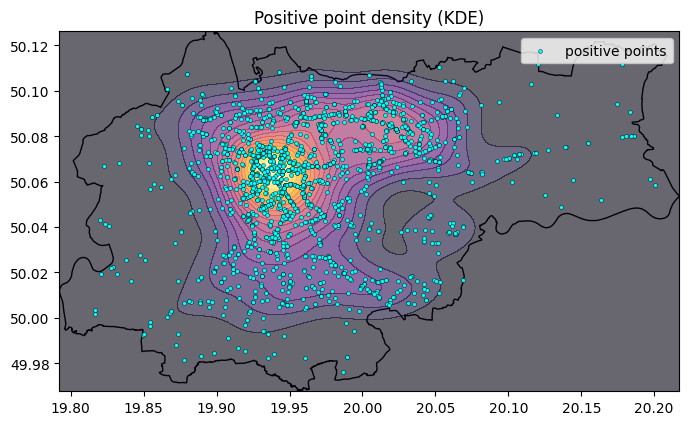

In [ ]:
# [Step 6a] QC — KDE heatmap of positive points =============================
fig, ax = plt.subplots(figsize=(8, 8))
boundary.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)

xy = np.vstack([pos["input_lon"], pos["input_lat"]])
kde = gaussian_kde(xy)
xmin, ymin, xmax, ymax = boundary.total_bounds
xx, yy = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
positions = np.vstack([xx.ravel(), yy.ravel()])
density = np.reshape(kde(positions), xx.shape)

ax.contourf(xx, yy, density, levels=20, cmap="inferno", alpha=0.6)
ax.scatter(pos["input_lon"], pos["input_lat"], s=8, c="cyan",
           edgecolor="k", linewidth=0.3, label="positive points")
ax.set_title("Positive point density (KDE)")
ax.legend()
plt.savefig(f"{OUTPUT_DIR}/qc_positive_kde.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# [Step 6b] QC — road-length availability per highway type ===================
total_neg = int(round(len(pos) * NEG_POS_RATIO))

diagnostic_rows = []
for hw, prop in highway_props.items():
    target_n = round(prop * total_neg)
    avail_len = edges_gdf.loc[edges_gdf["highway_clean"] == hw, "length"].sum()
    avg_spacing = avail_len / target_n if target_n > 0 else np.inf
    diagnostic_rows.append({
        "highway": hw,
        "target_proportion": round(prop, 3),
        "target_count": target_n,
        "available_road_length_m": round(avail_len, 1),
        "avg_spacing_if_generated_m": round(avg_spacing, 1),
        "flag": ("LOW AVAILABILITY - points will cluster"
                  if avg_spacing < LOW_AVAILABILITY_FLAG_M else "ok"),
    })

diagnostic_df = pd.DataFrame(diagnostic_rows)
print(diagnostic_df)
diagnostic_df.to_csv(f"{OUTPUT_DIR}/qc_road_availability.csv", index=False)

# Guidance:
#   If avg_spacing_if_generated_m is small (e.g. under ~20m) for a road type,
#   that type doesn't have enough distinct road length to generate its target
#   count without points landing very close together. Options: lower
#   NEG_POS_RATIO, lower MIN_DIST_FROM_POSITIVE_M, or accept the clustering.
#   Re-run this cell after changing either parameter to see the effect before
#   committing to Step 7's generation.

           highway  target_proportion  target_count  available_road_length_m  \
0      residential              0.301           559                1877277.6   
1         tertiary              0.296           550                 464529.4   
2          primary              0.165           307                 138072.2   
3        secondary              0.135           252                 148323.2   
4     unclassified              0.038            70                 180838.3   
5    living_street              0.025            46                 188312.3   
6     primary_link              0.015            27                  12763.0   
7   secondary_link              0.013            24                  10487.1   
8         motorway              0.005            10                  51574.3   
9    motorway_link              0.004             7                  17819.1   
10   tertiary_link              0.004             7                   1585.2   
11           trunk              0.001   

In [ ]:
# [Step 7] Generate negative points, matched to positive's road-type mix ====

def sample_points_on_edges(edges_subset, n, rng):
    """Weighted-by-length random point sampling along a set of edge geometries."""
    if len(edges_subset) == 0 or n <= 0:
        return []
    lengths = edges_subset["length"].values
    weights = lengths / lengths.sum()
    chosen_idx = rng.choice(len(edges_subset), size=n, p=weights, replace=True)
    out = []
    for idx in chosen_idx:
        geom = edges_subset.iloc[idx]["geometry"]
        frac = rng.uniform(0, 1)
        pt = geom.interpolate(frac, normalized=True)
        out.append(pt)
    return out


def far_enough_from_positives(pt, positive_points_utm, min_dist):
    if min_dist <= 0:
        return True
    return all(pt.distance(p) >= min_dist for p in positive_points_utm)


positive_points_utm = list(pos_gdf.geometry.values)
negative_records = []
neg_id_counter = 1

for hw, prop in highway_props.items():
    target_n = round(prop * total_neg)
    subset = edges_gdf[edges_gdf["highway_clean"] == hw]

    if len(subset) == 0:
        print(f"WARNING: no edges found for highway type '{hw}' — skipping "
              f"({target_n} negatives for this type will be missing).")
        continue

    accepted = 0
    attempts = 0
    max_attempts = target_n * 20 + 50  # safety cap against a stuck loop

    while accepted < target_n and attempts < max_attempts:
        batch = sample_points_on_edges(subset, target_n - accepted, rng)
        for pt in batch:
            attempts += 1
            if attempts > max_attempts:
                break
            if far_enough_from_positives(pt, positive_points_utm, MIN_DIST_FROM_POSITIVE_M):
                negative_records.append({"id": f"neg_{neg_id_counter}",
                                          "geometry": pt, "highway": hw})
                neg_id_counter += 1
                accepted += 1

    if accepted < target_n:
        print(f"WARNING: highway='{hw}' only reached {accepted}/{target_n} negatives "
              f"after {attempts} attempts — this road type may be too short or too "
              f"constrained by MIN_DIST_FROM_POSITIVE_M.")

neg_gdf = gpd.GeoDataFrame(negative_records, geometry="geometry", crs=utm_crs).to_crs(epsg=4326)
neg_gdf["lon"] = neg_gdf.geometry.x
neg_gdf["lat"] = neg_gdf.geometry.y

print(f"\nGenerated {len(neg_gdf)} negative points (target was {total_neg}).")
print(neg_gdf["highway"].value_counts(normalize=True).round(3))


Generated 1860 negative points (target was 1860).
highway
residential       0.301
tertiary          0.296
primary           0.165
secondary         0.135
unclassified      0.038
living_street     0.025
primary_link      0.015
secondary_link    0.013
motorway          0.005
motorway_link     0.004
tertiary_link     0.004
trunk             0.001
Name: proportion, dtype: float64


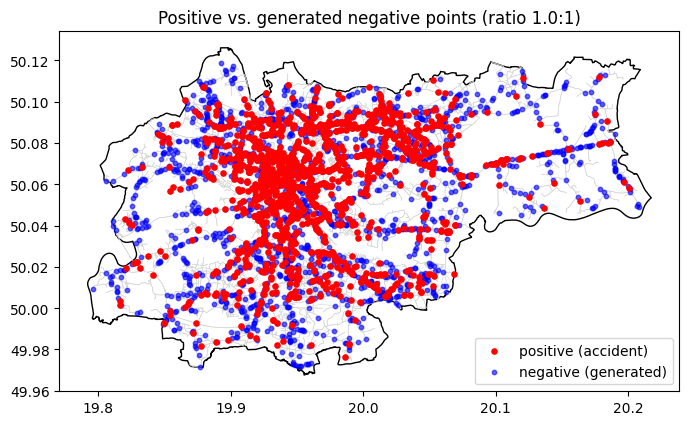

In [ ]:
# [Step 7 visualize] ==========================================================
fig, ax = plt.subplots(figsize=(8, 8))
boundary.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)
edges_gdf.to_crs(epsg=4326).plot(ax=ax, color="lightgray", linewidth=0.4, zorder=1)

ax.scatter(pos["input_lon"], pos["input_lat"], s=14, c="red",
           label="positive (accident)", zorder=3)
ax.scatter(neg_gdf["lon"], neg_gdf["lat"], s=10, c="blue", alpha=0.6,
           label="negative (generated)", zorder=2)
ax.set_title(f"Positive vs. generated negative points (ratio {NEG_POS_RATIO}:1)")
ax.legend()
plt.savefig(f"{OUTPUT_DIR}/qc_pos_vs_neg_map.png", dpi=150, bbox_inches="tight")
plt.show()

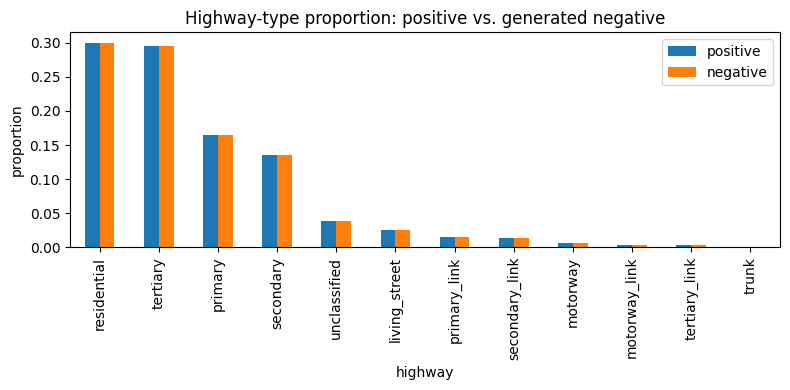

In [ ]:
# QC — did the generated negatives actually match the target proportions?
fig, ax = plt.subplots(figsize=(8, 4))
comp = pd.DataFrame({
    "positive": highway_props,
    "negative": neg_gdf["highway"].value_counts(normalize=True),
}).fillna(0)
comp.plot(kind="bar", ax=ax)
ax.set_ylabel("proportion")
ax.set_title("Highway-type proportion: positive vs. generated negative")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/qc_highway_proportion_match.png", dpi=150)
plt.show()

In [ ]:
# [Step 8] Final CSV outputs: id, lat, lon, highway ==========================
positive_out = pos[["id", "input_lat", "input_lon", "highway"]].rename(
    columns={"input_lat": "lat", "input_lon": "lon"}
)
negative_out = neg_gdf[["id", "lat", "lon", "highway"]]

positive_out.to_csv(f"{OUTPUT_DIR}/positive_points.csv", index=False)
negative_out.to_csv(f"{OUTPUT_DIR}/negative_points.csv", index=False)

print(f"\nSaved: {OUTPUT_DIR}/positive_points.csv  ({len(positive_out)} rows)")
print(f"Saved: {OUTPUT_DIR}/negative_points.csv  ({len(negative_out)} rows)")


Saved: /content/drive/MyDrive/crash-dualgraph/data/krakow/negative/positive_points.csv  (1860 rows)
Saved: /content/drive/MyDrive/crash-dualgraph/data/krakow/negative/negative_points.csv  (1860 rows)


## [Check] Kondisi setelah filtering: perbandingan positive vs negative per kelas jalan
Menggunakan 2 CSV baru (format sama seperti metadata mentah) dari root path baru.
Dijalankan setelah cell 'Step 2 setup' karena butuh `G_utm`, `edges_gdf`, `utm_crs`.

In [ ]:
NEW_POSITIVE_CSV = "/content/drive/MyDrive/crash-dualgraph/data/somerville/positive/metadata_outofrange_removed.csv"
NEW_NEGATIVE_CSV = "/content/drive/MyDrive/crash-dualgraph/data/somerville/negative/negative_points.csv"


def load_filter_snap(csv_path, label):
    """Load metadata CSV -> filter (status=='ok' & distance_m<=limit) -> snap ke road edge terdekat.
    Mengembalikan DataFrame dengan kolom: id, lat, lon, highway, snap_edge_dist_m.
    """
    raw = pd.read_csv(csv_path)
    print(f"[{label}] Loaded {len(raw)} rows from {csv_path}")

    df = raw[raw["status"] == "ok"].copy()
    before = len(df)
    df = df[df["distance_m"] <= DISTANCE_LIMIT_M].copy()
    print(f"[{label}] status=='ok': {before} rows -> distance_m <= {DISTANCE_LIMIT_M}m: "
          f"{len(df)} retained ({before - len(df)} excluded)")
    df = df.reset_index(drop=True)

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["input_lon"], df["input_lat"]),
        crs="EPSG:4326",
    ).to_crs(utm_crs)

    X = gdf.geometry.x.values
    Y = gdf.geometry.y.values
    nearest_edge, edge_dist = ox.distance.nearest_edges(G_utm, X=X, Y=Y, return_dist=True)

    highways = []
    for i in range(len(gdf)):
        u, v, k = nearest_edge[i]
        highways.append(edges_gdf.loc[(u, v, k), "highway_clean"])

    df["highway"] = highways
    df["snap_edge_dist_m"] = edge_dist

    out = df[["id", "input_lat", "input_lon", "highway", "snap_edge_dist_m"]].rename(
        columns={"input_lat": "lat", "input_lon": "lon"}
    )
    return out


# --- Snap ulang kedua kelas ---
positive_checked = load_filter_snap(NEW_POSITIVE_CSV, "positive")
negative_checked = load_filter_snap(NEW_NEGATIVE_CSV, "negative")

# --- Perbandingan jumlah & proporsi per kelas jalan ---
pos_counts = positive_checked["highway"].value_counts()
neg_counts = negative_checked["highway"].value_counts()

comparison = pd.DataFrame({
    "positive_n": pos_counts,
    "negative_n": neg_counts,
}).fillna(0).astype(int)

comparison["positive_prop"] = (comparison["positive_n"] / comparison["positive_n"].sum()).round(3)
comparison["negative_prop"] = (comparison["negative_n"] / comparison["negative_n"].sum()).round(3)
comparison["prop_diff"] = (comparison["positive_prop"] - comparison["negative_prop"]).round(3)
comparison = comparison.sort_values("positive_n", ascending=False)

print("\n=== Positive vs Negative comparison by highway type ===")
print(f"Total positive: {len(positive_checked)} | Total negative: {len(negative_checked)}")
print(comparison)

comparison.to_csv(f"{OUTPUT_DIR}/highway_comparison_post_filter.csv")
print(f"\nSaved: {OUTPUT_DIR}/highway_comparison_post_filter.csv")

# --- Visualization: raw counts, one grid panel per highway type ---
import seaborn as sns

plot_df = pd.concat([
    positive_checked.assign(label="Positive"),
    negative_checked.assign(label="Negative"),
])[["highway", "label"]]

count_df = (
    plot_df.groupby(["highway", "label"])
    .size()
    .reset_index(name="count")
)

highway_order = comparison.index.tolist()

g = sns.FacetGrid(
    count_df,
    col="highway",
    col_order=highway_order,
    col_wrap=4,
    height=3,
    sharey=False,
)
g.map_dataframe(
    sns.barplot,
    x="label",
    y="count",
    hue="label",
    order=["Positive", "Negative"],
    hue_order=["Positive", "Negative"],
    palette={"Positive": "#d62728", "Negative": "#1f77b4"},
)

for ax in g.axes.flat:
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f"{int(height)}", (p.get_x() + p.get_width() / 2, height),
                        ha="center", va="bottom", fontsize=9)

g.set_titles("{col_name}")
g.set_axis_labels("", "Count")
# g.fig.suptitle(
#     f"Positive vs. Negative Point Count by Highway Type "
#     f"(Total positive={len(positive_checked)}, negative={len(negative_checked)})",
#     y=1.03,
# )
plt.tight_layout()
g.savefig(f"{OUTPUT_DIR}/qc_post_filter_highway_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Export CSV final dengan keterangan highway ---
positive_checked.to_csv(f"{OUTPUT_DIR}/positive_points_with_highway.csv", index=False)
negative_checked.to_csv(f"{OUTPUT_DIR}/negative_points_with_highway.csv", index=False)

print(f"\nSaved: {OUTPUT_DIR}/positive_points_with_highway.csv  ({len(positive_checked)} rows)")
print(f"Saved: {OUTPUT_DIR}/negative_points_with_highway.csv  ({len(negative_checked)} rows)")

In [ ]:
NEW_POSITIVE_CSV = "/content/drive/MyDrive/crash-dualgraph/data/warsaw/positive/panorama/metadata_outofrange_removed.csv"
NEW_NEGATIVE_CSV = "/content/drive/MyDrive/crash-dualgraph/data/warsaw/negative/panorama/metadata_outofrange_removed.csv"


def load_filter_snap(csv_path, label):
    """Load metadata CSV -> filter (status=='ok' & distance_m<=limit) -> snap ke road edge terdekat.
    Mengembalikan DataFrame dengan kolom: id, lat, lon, highway, snap_edge_dist_m.
    """
    raw = pd.read_csv(csv_path)
    print(f"[{label}] Loaded {len(raw)} rows from {csv_path}")

    df = raw[raw["status"] == "ok"].copy()
    before = len(df)
    df = df[df["distance_m"] <= DISTANCE_LIMIT_M].copy()
    print(f"[{label}] status=='ok': {before} rows -> distance_m <= {DISTANCE_LIMIT_M}m: "
          f"{len(df)} retained ({before - len(df)} excluded)")
    df = df.reset_index(drop=True)

    gdf = gpd.GeoDataFrame(
        df,
        geometry=gpd.points_from_xy(df["input_lon"], df["input_lat"]),
        crs="EPSG:4326",
    ).to_crs(utm_crs)

    X = gdf.geometry.x.values
    Y = gdf.geometry.y.values
    nearest_edge, edge_dist = ox.distance.nearest_edges(G_utm, X=X, Y=Y, return_dist=True)

    highways = []
    for i in range(len(gdf)):
        u, v, k = nearest_edge[i]
        highways.append(edges_gdf.loc[(u, v, k), "highway_clean"])

    df["highway"] = highways
    df["snap_edge_dist_m"] = edge_dist

    out = df[["id", "input_lat", "input_lon", "highway", "snap_edge_dist_m"]].rename(
        columns={"input_lat": "lat", "input_lon": "lon"}
    )
    return out


# --- Snap ulang kedua kelas ---
positive_checked = load_filter_snap(NEW_POSITIVE_CSV, "positive")
negative_checked = load_filter_snap(NEW_NEGATIVE_CSV, "negative")

# --- Perbandingan jumlah & proporsi per kelas jalan ---
pos_counts = positive_checked["highway"].value_counts()
neg_counts = negative_checked["highway"].value_counts()

comparison = pd.DataFrame({
    "positive_n": pos_counts,
    "negative_n": neg_counts,
}).fillna(0).astype(int)

comparison["positive_prop"] = (comparison["positive_n"] / comparison["positive_n"].sum()).round(3)
comparison["negative_prop"] = (comparison["negative_n"] / comparison["negative_n"].sum()).round(3)
comparison["prop_diff"] = (comparison["positive_prop"] - comparison["negative_prop"]).round(3)
comparison = comparison.sort_values("positive_n", ascending=False)

print("\n=== Positive vs Negative comparison by highway type ===")
print(f"Total positive: {len(positive_checked)} | Total negative: {len(negative_checked)}")
print(comparison)

comparison.to_csv(f"{OUTPUT_DIR}/highway_comparison_post_filter.csv")
print(f"\nSaved: {OUTPUT_DIR}/highway_comparison_post_filter.csv")

# --- Visualization: raw counts, one grid panel per highway type ---
import seaborn as sns

plot_df = pd.concat([
    positive_checked.assign(label="Positive"),
    negative_checked.assign(label="Negative"),
])[["highway", "label"]]

count_df = (
    plot_df.groupby(["highway", "label"])
    .size()
    .reset_index(name="count")
)

highway_order = comparison.index.tolist()

g = sns.FacetGrid(
    count_df,
    col="highway",
    col_order=highway_order,
    col_wrap=4,
    height=3,
    sharey=False,
)
g.map_dataframe(
    sns.barplot,
    x="label",
    y="count",
    hue="label",
    order=["Positive", "Negative"],
    hue_order=["Positive", "Negative"],
    palette={"Positive": "#d62728", "Negative": "#1f77b4"},
)

for ax in g.axes.flat:
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            ax.annotate(f"{int(height)}", (p.get_x() + p.get_width() / 2, height),
                        ha="center", va="bottom", fontsize=9)

g.set_titles("{col_name}")
g.set_axis_labels("", "Count")
# g.fig.suptitle(
#     f"Positive vs. Negative Point Count by Highway Type "
#     f"(Total positive={len(positive_checked)}, negative={len(negative_checked)})",
#     y=1.03,
# )
plt.tight_layout()
g.savefig(f"{OUTPUT_DIR}/qc_post_filter_highway_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# --- Export CSV final dengan keterangan highway ---
positive_checked.to_csv(f"{OUTPUT_DIR}/positive_points_with_highway.csv", index=False)
negative_checked.to_csv(f"{OUTPUT_DIR}/negative_points_with_highway.csv", index=False)

print(f"\nSaved: {OUTPUT_DIR}/positive_points_with_highway.csv  ({len(positive_checked)} rows)")
print(f"Saved: {OUTPUT_DIR}/negative_points_with_highway.csv  ({len(negative_checked)} rows)")

In [ ]:
# [Step 2] Snap retained positives to nearest road edge =====================
pos_gdf = gpd.GeoDataFrame(
    pos,
    geometry=gpd.points_from_xy(pos["input_lon"], pos["input_lat"]),
    crs="EPSG:4326",
).to_crs(utm_crs)

X = pos_gdf.geometry.x.values
Y = pos_gdf.geometry.y.values
nearest_edge, edge_dist = ox.distance.nearest_edges(G_utm, X=X, Y=Y, return_dist=True)

highways, snap_lon, snap_lat = [], [], []
for i in range(len(pos_gdf)):
    u, v, k = nearest_edge[i]
    edge_row = edges_gdf.loc[(u, v, k)]
    highways.append(edge_row["highway_clean"])

    snapped_utm = nearest_points(edge_row.geometry, pos_gdf.geometry.iloc[i])[0]
    snapped_wgs = gpd.GeoSeries([snapped_utm], crs=utm_crs).to_crs(epsg=4326).iloc[0]
    snap_lon.append(snapped_wgs.x)
    snap_lat.append(snapped_wgs.y)

pos["highway"] = highways
pos["snap_edge_dist_m"] = edge_dist
pos["snap_lat"] = snap_lat
pos["snap_lon"] = snap_lon

print(pos[["id", "input_lat", "input_lon", "highway", "snap_edge_dist_m"]].head(10))

   id  input_lat  input_lon        highway  snap_edge_dist_m
0   6  52.224155  21.057552      secondary          3.013852
1   3  52.226749  20.996916      secondary          1.912260
2   2  52.248055  21.019166      secondary          0.983583
3   4  52.247333  20.953194       tertiary          3.306178
4   1  52.186138  21.064305      secondary          6.592634
5   7  52.247083  20.960556       tertiary          4.472596
6   9  52.260563  21.091425      secondary          2.626878
7  10  52.217638  21.164361       tertiary          0.333916
8  11  52.209194  20.929055    residential          1.312992
9  12  52.202959  20.938480  tertiary_link          0.450332


In [ ]:
# [Step 3] Highway-type distribution among positives ========================
highway_counts = pos["highway"].value_counts()
highway_props = pos["highway"].value_counts(normalize=True)

print("\nPositive point counts by road type:")
print(highway_counts)
print("\nProportions (target for negative generation):")
print(highway_props.round(3))


Positive point counts by road type:
highway
secondary         202
tertiary          170
residential       139
primary           107
motorway           18
motorway_link      16
living_street      15
primary_link       13
unclassified       12
trunk               6
tertiary_link       5
secondary_link      4
Name: count, dtype: int64

Proportions (target for negative generation):
highway
secondary         0.286
tertiary          0.240
residential       0.197
primary           0.151
motorway          0.025
motorway_link     0.023
living_street     0.021
primary_link      0.018
unclassified      0.017
trunk             0.008
tertiary_link     0.007
secondary_link    0.006
Name: proportion, dtype: float64


In [ ]:
# [Step 4] =====================================================================
# `highway_props` computed above IS the target distribution — carried forward
# directly into Step 7's generation loop. No separate transformation needed.

In [ ]:
# [Step 5] =====================================================================
# `boundary_union` (used in graph_from_polygon above) is the geographic
# constraint — the road graph itself never extends outside the study area,
# so every negative point generated below is automatically inside it.

In [ ]:
# [Step 6a] QC — KDE heatmap of positive points =============================
fig, ax = plt.subplots(figsize=(8, 8))
boundary.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)

xy = np.vstack([pos["input_lon"], pos["input_lat"]])
kde = gaussian_kde(xy)
xmin, ymin, xmax, ymax = boundary.total_bounds
xx, yy = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
positions = np.vstack([xx.ravel(), yy.ravel()])
density = np.reshape(kde(positions), xx.shape)

ax.contourf(xx, yy, density, levels=20, cmap="inferno", alpha=0.6)
ax.scatter(pos["input_lon"], pos["input_lat"], s=8, c="cyan",
           edgecolor="k", linewidth=0.3, label="positive points")
ax.set_title("Positive point density (KDE)")
ax.legend()
plt.savefig(f"{OUTPUT_DIR}/qc_positive_kde.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# [Step 6b] QC — road-length availability per highway type ===================
total_neg = int(round(len(pos) * NEG_POS_RATIO))

diagnostic_rows = []
for hw, prop in highway_props.items():
    target_n = round(prop * total_neg)
    avail_len = edges_gdf.loc[edges_gdf["highway_clean"] == hw, "length"].sum()
    avg_spacing = avail_len / target_n if target_n > 0 else np.inf
    diagnostic_rows.append({
        "highway": hw,
        "target_proportion": round(prop, 3),
        "target_count": target_n,
        "available_road_length_m": round(avail_len, 1),
        "avg_spacing_if_generated_m": round(avg_spacing, 1),
        "flag": ("LOW AVAILABILITY - points will cluster"
                  if avg_spacing < LOW_AVAILABILITY_FLAG_M else "ok"),
    })

diagnostic_df = pd.DataFrame(diagnostic_rows)
print(diagnostic_df)
diagnostic_df.to_csv(f"{OUTPUT_DIR}/qc_road_availability.csv", index=False)

# Guidance:
#   If avg_spacing_if_generated_m is small (e.g. under ~20m) for a road type,
#   that type doesn't have enough distinct road length to generate its target
#   count without points landing very close together. Options: lower
#   NEG_POS_RATIO, lower MIN_DIST_FROM_POSITIVE_M, or accept the clustering.
#   Re-run this cell after changing either parameter to see the effect before
#   committing to Step 7's generation.

In [ ]:
# [Step 7] Generate negative points, matched to positive's road-type mix ====

def sample_points_on_edges(edges_subset, n, rng):
    """Weighted-by-length random point sampling along a set of edge geometries."""
    if len(edges_subset) == 0 or n <= 0:
        return []
    lengths = edges_subset["length"].values
    weights = lengths / lengths.sum()
    chosen_idx = rng.choice(len(edges_subset), size=n, p=weights, replace=True)
    out = []
    for idx in chosen_idx:
        geom = edges_subset.iloc[idx]["geometry"]
        frac = rng.uniform(0, 1)
        pt = geom.interpolate(frac, normalized=True)
        out.append(pt)
    return out


def far_enough_from_positives(pt, positive_points_utm, min_dist):
    if min_dist <= 0:
        return True
    return all(pt.distance(p) >= min_dist for p in positive_points_utm)


positive_points_utm = list(pos_gdf.geometry.values)
negative_records = []
neg_id_counter = 1

for hw, prop in highway_props.items():
    target_n = round(prop * total_neg)
    subset = edges_gdf[edges_gdf["highway_clean"] == hw]

    if len(subset) == 0:
        print(f"WARNING: no edges found for highway type '{hw}' — skipping "
              f"({target_n} negatives for this type will be missing).")
        continue

    accepted = 0
    attempts = 0
    max_attempts = target_n * 20 + 50  # safety cap against a stuck loop

    while accepted < target_n and attempts < max_attempts:
        batch = sample_points_on_edges(subset, target_n - accepted, rng)
        for pt in batch:
            attempts += 1
            if attempts > max_attempts:
                break
            if far_enough_from_positives(pt, positive_points_utm, MIN_DIST_FROM_POSITIVE_M):
                negative_records.append({"id": f"neg_{neg_id_counter}",
                                          "geometry": pt, "highway": hw})
                neg_id_counter += 1
                accepted += 1

    if accepted < target_n:
        print(f"WARNING: highway='{hw}' only reached {accepted}/{target_n} negatives "
              f"after {attempts} attempts — this road type may be too short or too "
              f"constrained by MIN_DIST_FROM_POSITIVE_M.")

neg_gdf = gpd.GeoDataFrame(negative_records, geometry="geometry", crs=utm_crs).to_crs(epsg=4326)
neg_gdf["lon"] = neg_gdf.geometry.x
neg_gdf["lat"] = neg_gdf.geometry.y

print(f"\nGenerated {len(neg_gdf)} negative points (target was {total_neg}).")
print(neg_gdf["highway"].value_counts(normalize=True).round(3))

In [ ]:
# [Step 7 visualize] ==========================================================
fig, ax = plt.subplots(figsize=(8, 8))
boundary.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1)
edges_gdf.to_crs(epsg=4326).plot(ax=ax, color="lightgray", linewidth=0.4, zorder=1)

ax.scatter(pos["input_lon"], pos["input_lat"], s=14, c="red",
           label="positive (accident)", zorder=3)
ax.scatter(neg_gdf["lon"], neg_gdf["lat"], s=10, c="blue", alpha=0.6,
           label="negative (generated)", zorder=2)
ax.set_title(f"Positive vs. generated negative points (ratio {NEG_POS_RATIO}:1)")
ax.legend()
plt.savefig(f"{OUTPUT_DIR}/qc_pos_vs_neg_map.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# QC — did the generated negatives actually match the target proportions?
fig, ax = plt.subplots(figsize=(8, 4))
comp = pd.DataFrame({
    "positive": highway_props,
    "negative": neg_gdf["highway"].value_counts(normalize=True),
}).fillna(0)
comp.plot(kind="bar", ax=ax)
ax.set_ylabel("proportion")
ax.set_title("Highway-type proportion: positive vs. generated negative")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/qc_highway_proportion_match.png", dpi=150)
plt.show()

In [ ]:
# [Step 8] Final CSV outputs: id, lat, lon, highway ==========================
positive_out = pos[["id", "input_lat", "input_lon", "highway"]].rename(
    columns={"input_lat": "lat", "input_lon": "lon"}
)
negative_out = neg_gdf[["id", "lat", "lon", "highway"]]

positive_out.to_csv(f"{OUTPUT_DIR}/positive_points.csv", index=False)
negative_out.to_csv(f"{OUTPUT_DIR}/negative_points.csv", index=False)

print(f"\nSaved: {OUTPUT_DIR}/positive_points.csv  ({len(positive_out)} rows)")
print(f"Saved: {OUTPUT_DIR}/negative_points.csv  ({len(negative_out)} rows)")